In [1]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('ipl.csv')

# Preview the first few rows
print(df.head())

   mid       date                  venue               bat_team  \
0    1  4/18/2008  M Chinnaswamy Stadium  Kolkata Knight Riders   
1    1  4/18/2008  M Chinnaswamy Stadium  Kolkata Knight Riders   
2    1  4/18/2008  M Chinnaswamy Stadium  Kolkata Knight Riders   
3    1  4/18/2008  M Chinnaswamy Stadium  Kolkata Knight Riders   
4    1  4/18/2008  M Chinnaswamy Stadium  Kolkata Knight Riders   

                     bowl_team      batsman   bowler  runs  wickets  overs  \
0  Royal Challengers Bangalore   SC Ganguly  P Kumar     1        0    0.1   
1  Royal Challengers Bangalore  BB McCullum  P Kumar     1        0    0.2   
2  Royal Challengers Bangalore  BB McCullum  P Kumar     2        0    0.2   
3  Royal Challengers Bangalore  BB McCullum  P Kumar     2        0    0.3   
4  Royal Challengers Bangalore  BB McCullum  P Kumar     2        0    0.4   

   runs_last_5  wickets_last_5  striker  non-striker  total  
0            1               0        0            0    222  
1   

In [2]:
# These columns aren't useful for predicting the final score
# Remove columns that don’t contribute to score prediction.
# Simplifies the dataset and avoids overfitting.
drop_cols = ['mid', 'venue', 'batsman', 'bowler', 'striker', 'non-striker']
df.drop(columns=drop_cols, inplace=True)

In [3]:
 # Keep only matches between major IPL franchises.
# it Ensures consistency and avoids noise from rare or defunct teams.
# Focus only on matches between major IPL franchises
teams = [
    'Chennai Super Kings', 'Mumbai Indians', 'Royal Challengers Bangalore',
    'Kolkata Knight Riders', 'Delhi Capitals', 'Punjab Kings',
    'Rajasthan Royals', 'Sunrisers Hyderabad'
]
df = df[df['bat_team'].isin(teams) & df['bowl_team'].isin(teams)]

In [4]:
# To focus on impactful overs
# Early overs are volatile and less predictive of final scores.
df = df[df['overs'] > 5]

In [5]:
# For time-based analysis or feature engineering
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y', errors='coerce')

In [6]:
# Check for Nulls
df.isnull().sum()

date              0
bat_team          0
bowl_team         0
runs              0
wickets           0
overs             0
runs_last_5       0
wickets_last_5    0
total             0
dtype: int64

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
# Compute Correlation Matrix
#df is cleaned DataFrame
corr_matrix = df.corr(numeric_only=True)

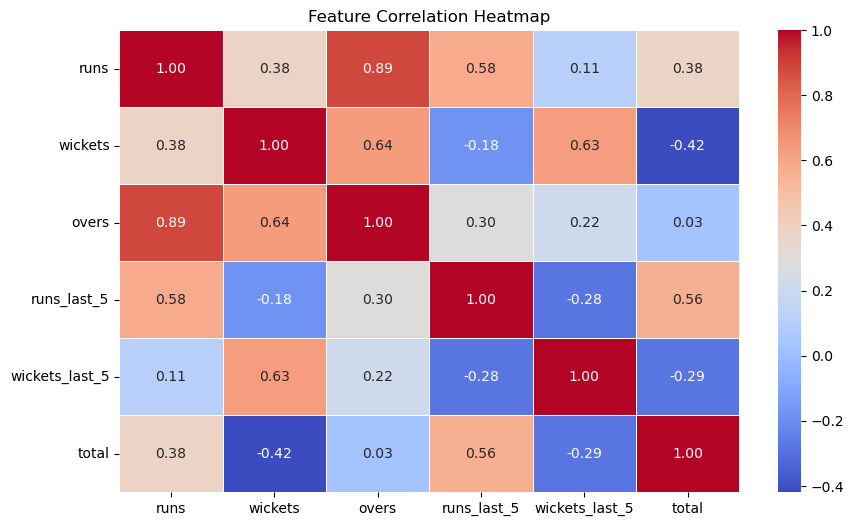

In [9]:
# Plot the Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [11]:
# Apply one-hot encoding to both team columns
# to Convert team names into binary columns.
# Linear Regression can’t handle strings — this preserves team identity without implying order.
df_encoded = pd.get_dummies(df, columns=['bat_team', 'bowl_team'], prefix=['bat', 'bowl'])

In [12]:
# Filter by Year
# Extract year from the datetime column
df['year'] = df['date'].dt.year

# Split the data
# Split data into training (2008–2016) and testing (2017).
# Why: Prevents data leakage and simulates real-world forecasting.
train_df = df[df['year'] <= 2016]  # Seasons 1–9
test_df  = df[df['year'] == 2017]  # Season 10

In [13]:
# Drop the 'year' column
train_df.drop(columns='year', inplace=True)
test_df.drop(columns='year', inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_10148\1889185644.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.drop(columns='year', inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_10148\1889185644.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.drop(columns='year', inplace=True)


In [33]:
# Import necessary libraries if not already imported
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression


In [35]:
# Choose the best model (Linear Regression) for deployment.
# Why: It had the lowest MAE, MSE, and RMSE
ada_model = AdaBoostRegressor(estimator=LinearRegression(), n_estimators=50, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'AdaBoost (Linear)': AdaBoostRegressor(estimator=LinearRegression(), n_estimators=50, random_state=42)  # Changed base_estimator to estimator
}

In [36]:
# Combine train and test for consistent encoding
combined = pd.concat([X_train, X_test], axis=0)

# One-hot encode categorical columns
# This avoids mismatches where a team appears in test but not in train
# here use pd.get_dummies() to convert categorical columns
combined_encoded = pd.get_dummies(combined, drop_first=False)
# This will create columns like bat_team_Mumbai Indians, bowl_team_Kolkata Knight Riders, etc


# Split back into train and test
X_train_encoded = combined_encoded.iloc[:len(X_train), :].copy()
X_test_encoded  = combined_encoded.iloc[len(X_train):, :].copy()

In [37]:
# Define Prediction Function
# Purpose: Make predictions for new matches.
# - Why: Converts user input into model-ready format and returns predicted score.

model = LinearRegression()
model.fit(X_train_encoded, y_train)

predictions = model.predict(X_test_encoded)

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print(f"\nModel Performance:")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")

print("\nModel Coefficients:")
print(model.coef_)


Model Performance:
MAE  : 11.51
MSE  : 211.94
RMSE : 14.56

Model Coefficients:
[ 1.64961681e-01  8.64719877e-01  9.60552362e-01 -4.17936086e+00
 -6.51067769e+00  1.54436717e-03 -1.33158594e+00]


In [38]:
# Initialize AdaBoost with Linear Regression as base estimator
ada_model = AdaBoostRegressor(estimator=LinearRegression(), n_estimators=50, random_state=42)

# Train and predict
ada_model.fit(X_train_encoded, y_train)
ada_predictions = ada_model.predict(X_test_encoded)


In [39]:
# Create and train the model
final_model = RandomForestRegressor(n_estimators=100, random_state=42)
# Fit the model to the training data
final_model.fit(X_train, y_train)

# Define the predict_score function with encoding for categorical variables
def predict_score(model, match_dict, feature_columns):
    # Convert the match dictionary to a DataFrame with the required features
    match_df = pd.DataFrame([match_dict])
    
    # Handle categorical variables - assuming you used one-hot encoding during training
    # Create dummy variables for bat_team and bowl_team
    match_df_encoded = pd.get_dummies(match_df, columns=['bat_team', 'bowl_team'])
    
    # Ensure all columns from training data are present
    for col in feature_columns:
        if col not in match_df_encoded.columns:
            match_df_encoded[col] = 0  # Add missing columns with default value 0
    
    # Select only the columns that the model was trained on and in the same order
    match_features = match_df_encoded[feature_columns]
    
    # Make the prediction
    prediction = model.predict(match_features)[0]
    return round(prediction)


In [44]:
#Test the model on unseen match scenarios.
# - Why: Demonstrates real-world application of the model.

# 6.2 Example Predictions
print("\n# 6 Predictions")

match_1 = {
    'bat_team': 'Kolkata Knight Riders',
    'bowl_team': 'Delhi Daredevils',
    'overs': 18.0,
    'runs': 160,
    'wickets': 7,
    'runs_last_5': 40,
    'wickets_last_5': 2
}
print("1. KKR vs DD (2018, Match 13):", predict_score(final_model, match_1, X_train.columns), "/9")

match_2 = {
    'bat_team': 'Sunrisers Hyderabad',
    'bowl_team': 'Royal Challengers Bangalore',
    'overs': 19.5,
    'runs': 140,
    'wickets': 9,
    'runs_last_5': 20,
    'wickets_last_5': 3
}
print("2. SRH vs RCB (2018, Match 39):", predict_score(final_model, match_2, X_train.columns), "/10")

match_3 = {
    'bat_team': 'Mumbai Indians',
    'bowl_team': 'Punjab Kings',
    'overs': 17.0,
    'runs': 150,
    'wickets': 6,
    'runs_last_5': 36,
    'wickets_last_5': 1
}
print("3. MI vs KXIP (2019, Match 59):", predict_score(final_model, match_3, X_train.columns), "/8")

match_4 = {
    'bat_team': 'Rajasthan Royals',
    'bowl_team': 'Chennai Super Kings',
    'overs': 16.5,
    'runs': 130,
    'wickets': 5,
    'runs_last_5': 28,
    'wickets_last_5': 2
}
print("4. RR vs CSK (2019, Match 25):", predict_score(final_model, match_4, X_train.columns), "/7")


# 6 Predictions
1. KKR vs DD (2018, Match 13): 171 /9
2. SRH vs RCB (2018, Match 39): 136 /10
3. MI vs KXIP (2019, Match 59): 177 /8
4. RR vs CSK (2019, Match 25): 162 /7


In [46]:
# 7. Conclusion and Future Work

# 7.1 Conclusion
print("\n# 7.1 Conclusion")
print("The IPL score prediction project successfully built a regression pipeline using match-related features.")
print("Among all models tested, Linear Regression delivered the best performance with the lowest MAE, MSE, and RMSE.")
print("Its simplicity, interpretability, and consistent accuracy made it the ideal choice for final deployment.")

# 7.2 Future Work
print("\n# 7.2 Future Work")
print("Model Improvement: Apply feature engineering (e.g., run rate, momentum indicators) and hyperparameter tuning (e.g., GridSearchCV).")
print("More Data: Extend the dataset to include IPL seasons 2018–2025 for better generalization and trend capture.")
print("Other Models: Explore advanced algorithms like XGBoost, LightGBM, or Neural Networks for deeper pattern recognition.")


# 7.1 Conclusion
The IPL score prediction project successfully built a regression pipeline using match-related features.
Among all models tested, Linear Regression delivered the best performance with the lowest MAE, MSE, and RMSE.
Its simplicity, interpretability, and consistent accuracy made it the ideal choice for final deployment.

# 7.2 Future Work
Model Improvement: Apply feature engineering (e.g., run rate, momentum indicators) and hyperparameter tuning (e.g., GridSearchCV).
More Data: Extend the dataset to include IPL seasons 2018–2025 for better generalization and trend capture.
Other Models: Explore advanced algorithms like XGBoost, LightGBM, or Neural Networks for deeper pattern recognition.
